In [235]:
import pandas as pd
import sys
import os
import re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.transforms as mtransforms

In [236]:
def get_path_up_to(current_path, directory_name):
    # Split the path into its components
    path_components = current_path.split(os.sep)

    # Find the index of the target directory in the path components
    if directory_name in path_components:
        target_index = path_components.index(directory_name)
        # Join the path components up to and including the target directory
        truncated_path = os.sep.join(path_components[:target_index])
        return truncated_path
    else:
        raise ValueError(f"Directory '{directory_name}' not found in the current file path")

def get_patient(file_name: str) -> int:
    match = re.search(r"_p(\d+)_", file_name)
    if match:
        return int(match.group(1))
    else:
        return -1

In [237]:
repo_path = get_path_up_to(os.getcwd(), "eda")
dir_path = repo_path + '/data/input/'
annotation_path = dir_path + 'annotations_exc_1-6.csv'
set_paths = {set: dir_path + 'set_indices/' + f'test15_val15_{set}.txt' for set in ["train", "val", "test"]}

In [238]:
set_paths

{'train': '/home/dascim/repos/histograph/data/input/set_indices/test15_val15_train.txt',
 'val': '/home/dascim/repos/histograph/data/input/set_indices/test15_val15_val.txt',
 'test': '/home/dascim/repos/histograph/data/input/set_indices/test15_val15_test.txt'}

In [239]:
df_annotation = pd.read_csv(annotation_path, delimiter=',')
set_dfs = {set: pd.read_csv(path, header=None, names=['index']) for set, path in set_paths.items()}

In [240]:
set_sizes= {}
for set, df in set_dfs.items():
    df_patient = df_annotation[["ID", "Image filename"]]
    df_patient["patient"] = df_patient["Image filename"].apply(lambda s: s.split('_')[2])
    df_patient.drop("Image filename", axis=1, inplace = True)
    
    df = pd.merge(df, df_patient, left_on='index', right_on="ID")
    patient_counts = df['patient'].value_counts()
    print(set)
    print(patient_counts)

train
patient
001    361
002    198
004    192
003     73
Name: count, dtype: int64
val
patient
001    75
002    42
004    41
003    16
Name: count, dtype: int64
test
patient
001    78
002    43
004    42
003    16
Name: count, dtype: int64


/tmp/ipykernel_581303/2487616165.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_patient["patient"] = df_patient["Image filename"].apply(lambda s: s.split('_')[2])
/tmp/ipykernel_581303/2487616165.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_patient.drop("Image filename", axis=1, inplace = True)
/tmp/ipykernel_581303/2487616165.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

In [241]:
patient_counts['001']

78

## Create file for zeeshan

In [242]:
df_annotation["patient"] = df_annotation["Image filename"].apply(lambda s: s.split('_')[2])
df_annotation["stain"] = df_annotation["Image filename"].apply(lambda s: s.split('_')[-1].split('.')[0])
df_annotation_filtered = df_annotation[df_annotation['patient'].isin(['001','002','003','004','005','006'])]
df_annotation_filtered = df_annotation_filtered[df_annotation_filtered['stain'] == '25']
df_annotation_filtered.loc[:,'train set'] = df_annotation_filtered['ID'].apply(lambda id : int(id) in list(set_dfs['train']['index']))
df_annotation_filtered.loc[:,'validation set'] = df_annotation_filtered['ID'].apply(lambda id : int(id) in list(set_dfs['val']['index']))
df_annotation_filtered.loc[:,'test set'] = df_annotation_filtered['ID'].apply(lambda id : int(id) in list(set_dfs['test']['index']))
indices_004 = df_annotation_filtered[df_annotation_filtered['patient'].apply(lambda p: p in ['004','005','006'])].index
df_annotation_filtered.loc[indices_004,'test set'] = True
df_annotation_filtered.loc[indices_004,'validation set'] = False
df_annotation_filtered.loc[indices_004,'train set'] = False

In [243]:
#df_annotation_filtered.to_csv('dataset_zeeshan.csv')

In [244]:
df_annotation['patient'].value_counts()

patient
006    528
001    514
005    346
002    283
004    275
003    105
Name: count, dtype: int64

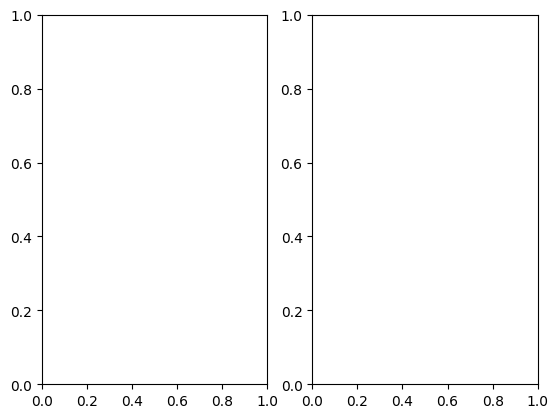

In [245]:
fig, axes = plt.subplots(1,2)

df_plot = df_annotation_filtered[df_annotation_filtered['patient'].apply(lambda p: p not in ['004','005','006'])].groupby(['test set', 'Term']).size().reset_index().pivot(columns='Term', index='test set', values=0)
desired_order = ["Healthy", "Sclerotic", "Dead"]
df_plot = df_plot[desired_order]
totals = df_plot.sum(axis=1)

In [246]:
df_annotation_between = df_annotation_filtered.copy()
df_annotation_between["test set"] = df_annotation_between['patient'].apply(lambda p: p in ['004','005','006'])
df_plot2 = df_annotation_between.groupby(['test set', 'Term']).size().reset_index().pivot(columns='Term', index='test set', values=0)
desired_order = ["Healthy", "Sclerotic", "Dead"]
df_plot2 = df_plot2[desired_order]

In [247]:
df_plot2 = df_plot2.rename_axis("Between patients", axis="index")
df_plot = df_plot.rename_axis("Within patients", axis="index")

In [248]:
df_plot2

Term,Healthy,Sclerotic,Dead
Between patients,,,
False,696.0,115.0,91.0
True,630.0,302.0,216.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_581303/3135106963.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


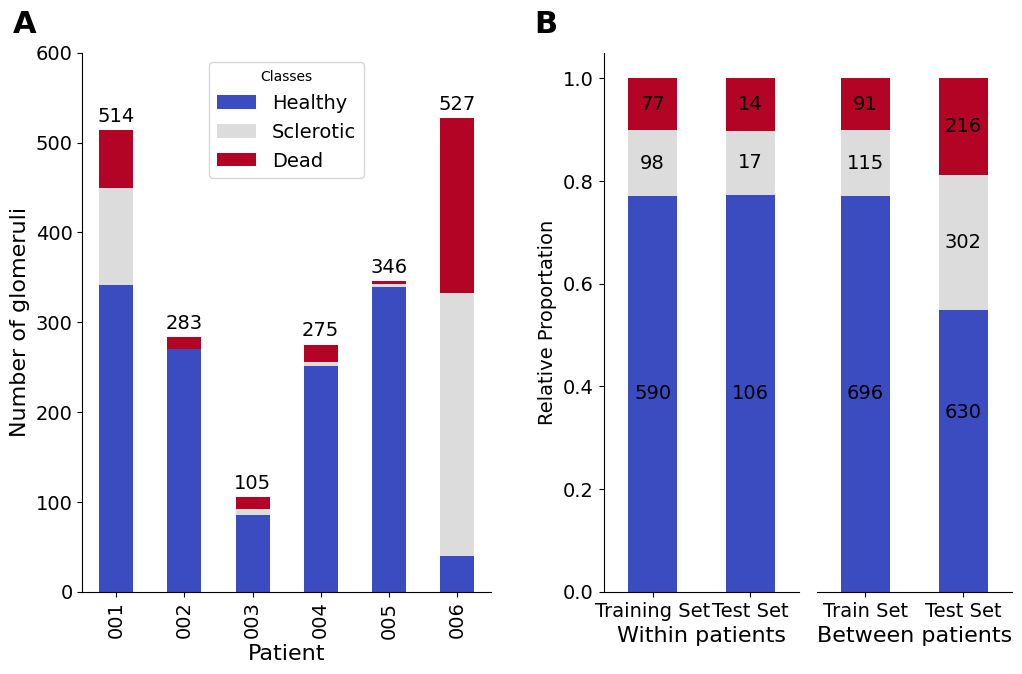

In [249]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Create a figure with GridSpec
fig = plt.figure(figsize=(12,7))
gs = gridspec.GridSpec(1,5, wspace=0.1, width_ratios=[1,1,0.4,1,1])#, height_ratios=[1, 0.7])  # adjust height_ratios as needed
fontsize=14

# Axes for first figure (two subplots)
ax_left = fig.add_subplot(gs[0, 3])
ax_right = fig.add_subplot(gs[0, 4])

# Axis for second figure (spanning both columns)
ax_bottom = fig.add_subplot(gs[0, :2])

# ----- First figure code (update to use ax_left and ax_right) -----
# Convert to relative proportions
df_relative = df_plot.div(df_plot.sum(axis=1), axis=0)
df_relative.plot(kind="bar", stacked=True, colormap="coolwarm", ax=ax_left, fontsize=fontsize)
ax_left.set_ylabel("Relative Proportion")
# Annotate ax_left as in your code ...
for bar_group, (idx, row) in enumerate(df_plot.iterrows()):
    bottom = 0
    for col, value in row.items():
        relative_value = df_relative.loc[idx, col]
        absolute_value = int(value)
        x_position = bar_group
        y_position = bottom + relative_value / 2
        ax_left.text(x_position, y_position, str(absolute_value),
                     ha="center", va="center", fontsize=fontsize, color="black")
        bottom += relative_value
ax_left.set_xticklabels(["Training Set", "Test Set"], rotation=0, fontsize=fontsize)

df_relative2 = df_plot2.div(df_plot2.sum(axis=1), axis=0)
df_relative2.plot(kind="bar", stacked=True, colormap="coolwarm", ax=ax_right, fontsize=fontsize)
for bar_group, (idx, row) in enumerate(df_plot2.iterrows()):
    bottom = 0
    for col, value in row.items():
        relative_value = df_relative2.loc[idx, col]
        absolute_value = int(value)
        x_position = bar_group if relative_value > 0.05 else bar_group - 0.3
        y_position = bottom + relative_value / 2 if (bottom + relative_value / 2) > 0.35 else 0.35
        ax_right.text(x_position, y_position, str(absolute_value),
                      ha="center", va="center", fontsize=fontsize, color="black")
        bottom += relative_value
ax_right.set_xticklabels(["Train Set", "Test Set"], rotation=0, fontsize=fontsize)
ax_right.tick_params(left=False, bottom=True)
ax_right.spines[['left','right','top']].set_visible(False)
ax_left.spines[['right','top']].set_visible(False)
ax_right.yaxis.set_visible(False)
ax_left.set_xlabel("Within patients", fontsize=fontsize+2)
ax_right.set_xlabel("Between patients", fontsize=fontsize+2)
ax_bottom.legend(title="Classes", loc="lower right", fontsize=fontsize)
ax_left.set_ylabel("Relative Proportation", fontsize=fontsize)
ax_left.get_legend().remove()
ax_right.get_legend().remove()

# ----- Second figure code (update to use ax_bottom) -----
df_plot_patient = df_annotation_filtered.groupby(['patient', 'Term']).size().reset_index().pivot(
    columns='Term', index='patient', values=0)
desired_order = ["Healthy", "Sclerotic", "Dead"]
df_plot_patient = df_plot_patient[desired_order]
totals = df_plot_patient.sum(axis=1)

df_plot_patient.plot(kind='bar', stacked=True, colormap="coolwarm", ylim=(0,550),
                       fontsize=fontsize, ax=ax_bottom)
rects = ax_bottom.patches
# Annotate the last 6 bars (as in your code)
for rect, label in zip(rects[-6:], totals):
    height = label
    ax_bottom.text(rect.get_x() + rect.get_width() / 2, height + 5, int(label),
                   ha="center", va="bottom", fontsize=fontsize)
#ax_bottom.legend(title="Classes", fontsize=fontsize)
ax_bottom.set_ylim((0,600))
ax_bottom.set_xlabel("Patient", fontsize=fontsize+2)
ax_bottom.set_ylabel("Number of glomeruli", fontsize=fontsize+2)
ax_bottom.legend(title="Classes", fontsize=fontsize)
ax_bottom.spines[['right','top']].set_visible(False)

# Define an offset (in points, here 10 points left and 10 points up)
offset = mtransforms.ScaledTranslation(-50/72, 10/72, fig.dpi_scale_trans)
ax_bottom.text(0, 1, "A", transform=ax_bottom.transAxes + offset,
             fontsize=font_size+10, fontweight='bold',
             va='bottom', ha='left')
ax_left.text(0, 1, "B", transform=ax_left.transAxes + offset,
             fontsize=font_size+10, fontweight='bold',
             va='bottom', ha='left')

plt.tight_layout()
plt.savefig('exc_combined_figure.pdf', bbox_inches='tight')
plt.show()


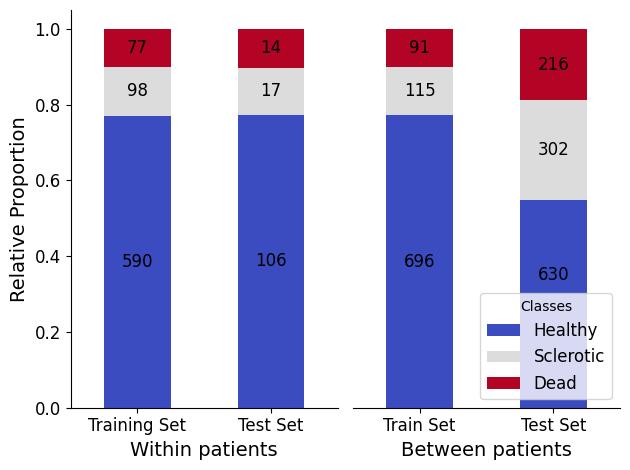

In [250]:
font_size = 12

fig, axes = plt.subplots(1,2)
# Convert to relative proportions
df_relative = df_plot.div(df_plot.sum(axis=1), axis=0)

# Plot the relative stacked bar chart
df_relative.plot(kind="bar", stacked=True, colormap="coolwarm", ax = axes[0],fontsize=font_size)
axes[0].set_ylabel("Relative Proportion")

# Annotate with absolute numbers
for bar_group, (idx, row) in enumerate(df_plot.iterrows()):
    bottom = 0  # Track the bottom of each stack
    for col, value in row.items():
        relative_value = df_relative.loc[idx, col]
        absolute_value = int(value)
        # Find the center of the current stack
        x_position = bar_group
        y_position = bottom + relative_value / 2
        axes[0].text(
            x_position, 
            y_position, 
            str(absolute_value), 
            ha="center", 
            va="center", 
            fontsize=font_size, 
            color="black"
        )
        bottom += relative_value

# Customize x-axis
axes[0].set_xticklabels(["Training Set", "Test Set"], rotation=0, fontsize=font_size)



df_relative2 = df_plot2.div(df_plot2.sum(axis=1), axis=0)

# Plot the relative stacked bar chart
df_relative2.plot(kind="bar", stacked=True, colormap="coolwarm", ax = axes[1],fontsize=font_size)

# Annotate with absolute numbers
for bar_group, (idx, row) in enumerate(df_plot2.iterrows()):
    bottom = 0  # Track the bottom of each stack
    for col, value in row.items():
        relative_value = df_relative2.loc[idx, col]
        absolute_value = int(value)
        # Find the center of the current stack
        x_position = bar_group if relative_value > 0.05 else bar_group - 0.3
        y_position = bottom + relative_value / 2 if (bottom + relative_value / 2) > 0.35 else 0.35
        axes[1].text(
            x_position, 
            y_position, 
            str(absolute_value), 
            ha="center", 
            va="center", 
            fontsize=font_size, 
            color="black"
        )
        bottom += relative_value

# Customize x-axis
axes[1].set_xticklabels(["Train Set", "Test Set"], rotation=0, fontsize=font_size)
axes[1].tick_params(left=False, bottom=True)
axes[1].spines[['left','right','top']].set_visible(False)
axes[0].spines[['right','top']].set_visible(False)
axes[1].yaxis.set_visible(False)

for ax in axes:
    ax.set_xlabel(ax.get_xlabel(), fontsize=font_size+2)  # Keep existing label but change font size
    ax.set_ylabel(ax.get_ylabel(), fontsize=font_size+2)

# Show legend and save the plot
axes[1].legend(title="Classes", loc="lower right",fontsize=font_size)
axes[0].get_legend().remove()
plt.tight_layout()
plt.savefig('exc_by_class.pdf')
plt.show()

Term
Healthy      1326.0
Sclerotic     417.0
Dead          307.0
dtype: float64


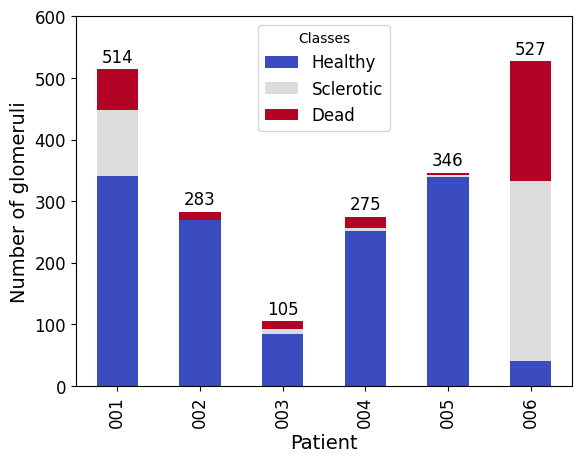

In [251]:
font_size = 12
df_plot = df_annotation_filtered.groupby(['patient', 'Term']).size().reset_index().pivot(columns='Term', index='patient', values=0)
desired_order = ["Healthy", "Sclerotic", "Dead"]
df_plot = df_plot[desired_order]
totals = df_plot.sum(axis=1)

print(df_plot.sum(axis=0))

ax = df_plot.plot(kind='bar', stacked=True, colormap="coolwarm", ylim=(0,550), fontsize=font_size)
rects=ax.patches
for i, (rect, label) in enumerate(zip(rects[-6:], totals)):
    height = label
    ax.text(
        rect.get_x() + rect.get_width() / 2, height + 5, int(label), ha="center", va="bottom", fontsize=font_size
    )
ax.legend(title="Classes", fontsize=font_size)
ax.set_ylim((0,600))
ax.set_xlabel(ax.get_xlabel(), fontsize=font_size+2)  # Keep existing label but change font size
ax.set_ylabel(ax.get_ylabel(), fontsize=font_size+2)
plt.xlabel("Patient")
plt.ylabel("Number of glomeruli")
plt.savefig('exc_by_patient.pdf',bbox_inches='tight')